In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## SSD WITH MOMENTUM

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.layers import Dense , Dropout
from keras.optimizers import SGD
from keras.models import Sequential
# 1. Load and preprocess data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 28*28).astype("float32") / 255.0

# create archituter 


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(10, activation="softmax")
])
# initialize optimizer
optimizer = SGD(
    learning_rate = 0.01,
    momentum = 0.9,
    nesterov=True  
)

# compile the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer = optimizer,
              metrics = ["accuracy"]
             )
# 4. Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)





2026-03-15 02:13:01.655547: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773540781.917980      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773540781.991419      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773540782.590436      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773540782.590499      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773540782.590503      17 computation_placer.cc:177] computation placer alr

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-15 02:13:31.871652: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6556 - loss: 1.0710 - val_accuracy: 0.9390 - val_loss: 0.2125
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9021 - loss: 0.3333 - val_accuracy: 0.9533 - val_loss: 0.1554
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9272 - loss: 0.2492 - val_accuracy: 0.9645 - val_loss: 0.1255
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9354 - loss: 0.2118 - val_accuracy: 0.9683 - val_loss: 0.1085
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9444 - loss: 0.1885 - val_accuracy: 0.9708 - val_loss: 0.0994
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9499 - loss: 0.1681 - val_accuracy: 0.9727 - val_loss: 0.0923
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9561 - loss: 0.1499 - val_accuracy: 0.9757 - val_loss: 0.0859
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9586 - loss: 0.1369 - val_accuracy: 0.

test_accuracy = 0.9726999998092651 


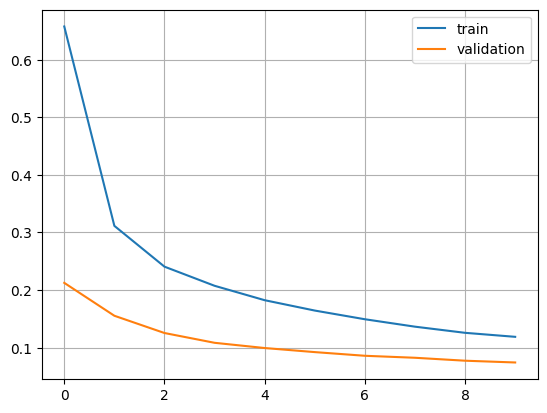

In [3]:
# Evaluate 
import matplotlib.pyplot as plt
test_loss , test_accuracy = model.evaluate(x_test,y_test,verbose=0)
print(f"test_accuracy = {test_accuracy} ")
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(['train','validation'])
plt.grid()
plt.show()

## Adagrad optimizer

In [4]:
from keras.optimizers import Adagrad
optimizer = Adagrad(learning_rate=0.01)
model.compile(optimizer = optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )

# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9668 - loss: 0.1073 - val_accuracy: 0.9790 - val_loss: 0.0751
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9689 - loss: 0.1012 - val_accuracy: 0.9790 - val_loss: 0.0719
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9697 - loss: 0.0969 - val_accuracy: 0.9792 - val_loss: 0.0720
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9705 - loss: 0.0923 - val_accuracy: 0.9800 - val_loss: 0.0680
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9738 - loss: 0.0835 - val_accuracy: 0.9798 - val_loss: 0.0675
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9733 - loss: 0.0869 - val_accuracy: 0.9800 - val_loss: 0.0663
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9748 - loss: 0.0806 - val_accuracy: 0.9805 - val_loss: 0.0663
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9759 - loss: 0.0795 - 

In [5]:
# evalute the result
test_loss , test_acc = model.evaluate(x_test,y_test,verbose=0)
print(f"test accuracy is : {test_acc}")


test accuracy is : 0.9789000153541565


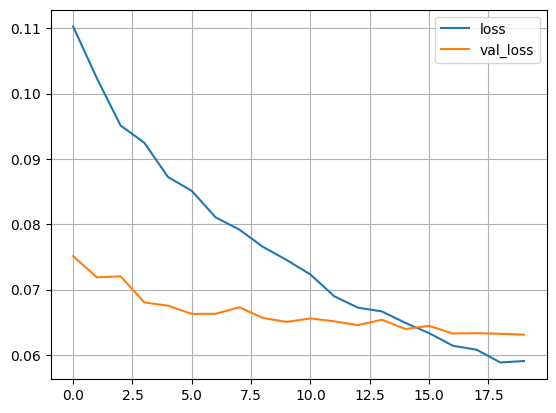

In [6]:
# visulize the model
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss","val_loss"])
plt.grid()
plt.show()

## RMSprop optimizer

In [7]:
from keras.optimizers import RMSprop
RMS_optimizer = RMSprop(
    learning_rate = 0.001,
    rho=0.9,
    epsilon = 1e-7
)

In [8]:
model.compile(optimizer = RMS_optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )

# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9705 - loss: 0.0963 - val_accuracy: 0.9757 - val_loss: 0.0911
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9699 - loss: 0.1012 - val_accuracy: 0.9793 - val_loss: 0.0816
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9729 - loss: 0.0900 - val_accuracy: 0.9775 - val_loss: 0.0891
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9740 - loss: 0.0935 - val_accuracy: 0.9788 - val_loss: 0.0815
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9767 - loss: 0.0840 - val_accuracy: 0.9802 - val_loss: 0.0827
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9772 - loss: 0.0871 - val_accuracy: 0.9805 - val_loss: 0.0839
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9796 - loss: 0.0819 - val_accuracy: 0.9815 - val_loss: 0.0799
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9787 - loss: 0.0813 - 

In [9]:
# evalute the result
test_loss , test_acc = model.evaluate(x_test,y_test,verbose=0)
print(f"test accuracy is : {test_acc}")


test accuracy is : 0.9779000282287598


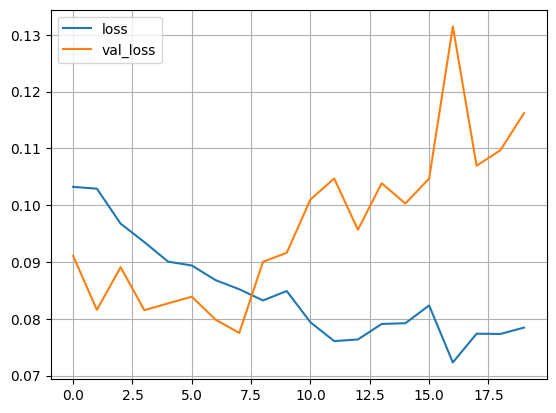

In [10]:
# visulize the model
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss","val_loss"])
plt.grid()
plt.show()

# Adam optimizer

In [11]:
from keras.optimizers import Adam
model.compile(optimizer = "Adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"]
             )

# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)
# fit the model 
history=model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size = 32,
    validation_split = 0.1,
    verbose = 1
    
)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9776 - loss: 0.0886 - val_accuracy: 0.9795 - val_loss: 0.1049
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9775 - loss: 0.0816 - val_accuracy: 0.9805 - val_loss: 0.0876
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9791 - loss: 0.0728 - val_accuracy: 0.9803 - val_loss: 0.0919
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9801 - loss: 0.0690 - val_accuracy: 0.9798 - val_loss: 0.0928
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9819 - loss: 0.0606 - val_accuracy: 0.9822 - val_loss: 0.0847
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9822 - loss: 0.0594 - val_accuracy: 0.9827 - val_loss: 0.0855
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9822 - loss: 0.0590 - val_accuracy: 0.9802 - val_loss: 0.0954
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9824 - loss: 0.0562 - 

In [12]:
# evalute the result
test_loss , test_acc = model.evaluate(x_test,y_test,verbose=0)
print(f"test accuracy is : {test_acc}")


test accuracy is : 0.9794999957084656


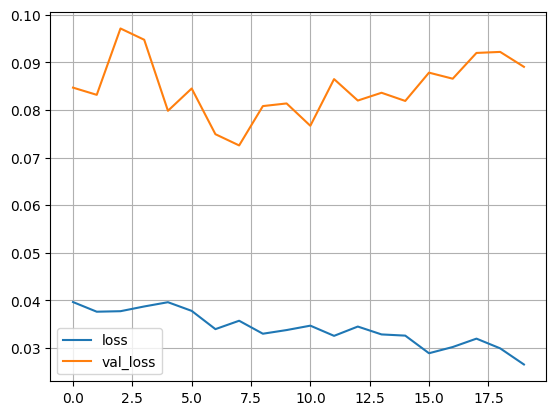

In [13]:
# visulize the model
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss","val_loss"])
plt.grid()
plt.show()